# RiMEA 8: Parameter Analysis

A 3-floor building (ground floor + 2 upper floors) is populated with 120 persons (4 per room, 5 rooms per side per floor, 2 sides per floor).  
The total evacuation time is recorded while the desired speed **v₀** is varied:

1. **Constant v₀** – every agent gets the same fixed speed: 0.5 / 0.75 / 1.0 / 1.25 m/s  
2. **Statistically distributed v₀** – speeds drawn from a uniform distribution centred on the fixed mean, with two different spreads: U(0.5, 1.0) and U(0.25, 1.25)

Expected result: total evacuation time decreases monotonically as v₀ increases.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 02 July 2026, 10:24 CEST


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from shapely.plotting import plot_polygon
import jupedsim as jps
import sys

sys.path.insert(0, str(Path("scenario_builders").resolve()))
# scenario builder for this test
from rimea08_parameter import (
    build_geometry, build_simulation, run_until_evacuation,
    v0_constant, v0_uniform,
    N_AGENTS, FLOOR_W, FLOOR_H, FLOOR_STRIDE, ROOM_D, CORRIDOR_W, N_FLOORS,
)

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Building Geometry

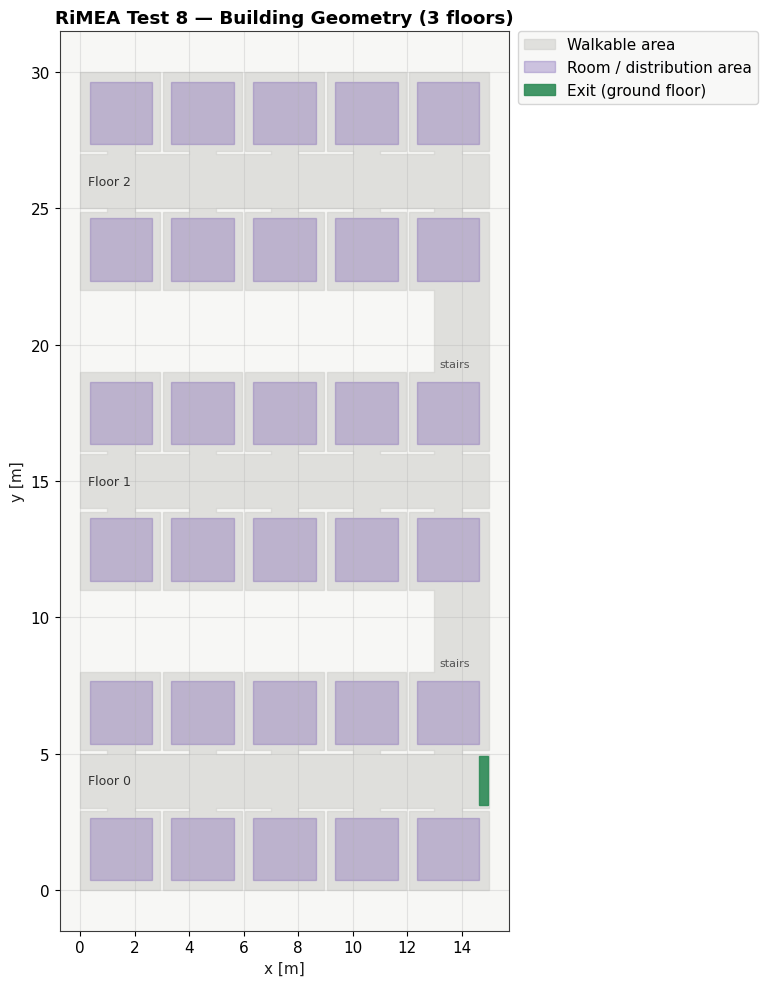

In [4]:
geometry, room_polys = build_geometry()

fig, ax = plt.subplots(figsize=(8, 10))
plot_polygon(geometry, ax=ax, color="#d0d0cc", alpha=0.6, add_points=False)

# shade each room distribution area
for rp in room_polys:
    plot_polygon(rp, ax=ax, color="#7b5fb3", alpha=0.35, add_points=False)

# mark exit
from shapely.geometry import box as sbox
exit_viz = sbox(FLOOR_W - 0.35, ROOM_D + 0.1, FLOOR_W - 0.05, ROOM_D + CORRIDOR_W - 0.1)
plot_polygon(exit_viz, ax=ax, color="#2e8b57", alpha=0.9, add_points=False)

# annotate floors and stairs
for f in range(N_FLOORS):
    y0 = f * FLOOR_STRIDE
    ax.text(0.3, y0 + FLOOR_H / 2, f"Floor {f}", fontsize=9,
            va="center", color="#333333")
    if f < N_FLOORS - 1:
        ax.text(FLOOR_W - 1.8, y0 + FLOOR_H + 0.2, "stairs",
                fontsize=8, color="#555555")

legend_handles = [
    mpatches.Patch(color="#d0d0cc", alpha=0.6, label="Walkable area"),
    mpatches.Patch(color="#7b5fb3", alpha=0.35, label="Room / distribution area"),
    mpatches.Patch(color="#2e8b57", alpha=0.9, label="Exit (ground floor)"),
]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0)
ax.set_aspect("equal")
ax.set_title("RiMEA Test 8 — Building Geometry (3 floors)")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
plt.tight_layout()
plt.show()

## Parameter Sweep — Constant v₀

Every agent gets the same fixed desired speed. We sweep over {0.5, 0.75, 1.0, 1.25} m/s and record the total evacuation time.

In [21]:
CONSTANT_V0_VALUES = [1.0, 1.25,1.50,2.00]   # m/s
SEED = 42

constant_results = []   # list of dict

for v0 in CONSTANT_V0_VALUES:
    sim, exit_id = build_simulation(v0_constant(v0), seed=SEED)
    evac_time, n_evac = run_until_evacuation(sim, max_time=600.0)
    constant_results.append({
        "v0": v0,
        "evac_time": evac_time,
        "n_evacuated": n_evac,
    })
    print(f"v0 = {v0:.2f} m/s  →  evacuation time = {evac_time:.1f} s  "
          f"({n_evac}/{N_AGENTS} evacuated)")

df_constant = pd.DataFrame(constant_results)
print()
print(df_constant.to_string(index=False))

v0 = 1.00 m/s  →  evacuation time = 103.4 s  (120/120 evacuated)
v0 = 1.25 m/s  →  evacuation time = 95.8 s  (120/120 evacuated)
v0 = 1.50 m/s  →  evacuation time = 89.5 s  (120/120 evacuated)
v0 = 2.00 m/s  →  evacuation time = 82.3 s  (120/120 evacuated)

  v0  evac_time  n_evacuated
1.00     103.40          120
1.25      95.75          120
1.50      89.45          120
2.00      82.30          120


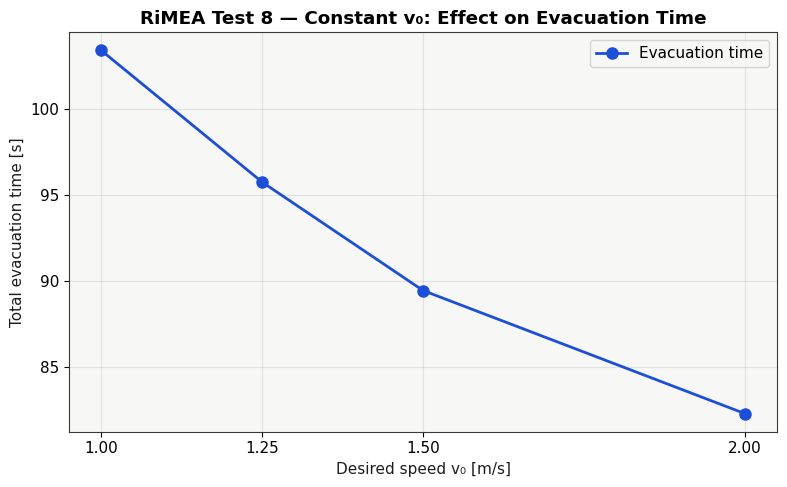

In [22]:
fig, ax = plt.subplots()
ax.plot(df_constant["v0"], df_constant["evac_time"],
        marker="o", color="#1d4ed8", linewidth=2, markersize=8, label="Evacuation time")

ax.set_xlabel("Desired speed v₀ [m/s]")
ax.set_ylabel("Total evacuation time [s]")
ax.set_title("RiMEA Test 8 — Constant v₀: Effect on Evacuation Time")
ax.set_xticks(CONSTANT_V0_VALUES)
ax.legend()
plt.tight_layout()
plt.show()

## Parameter Sweep — Statistically Distributed v₀

Speeds are drawn from a uniform distribution centred on the fixed mean (0.75 m/s) with two different spreads, and compared against the same fixed mean run:

| Case | Distribution | Mean | Std approx |
|---|---|---|---|
| Fixed mean | constant 1.25 | 1.25 | 0.00 |
| U(1.00, 1.50) | uniform, ±0.25 | 1.25 | 0.14 |
| U(0.75, 1.75) | uniform, ±0.50 | 1.25 | 0.29 |

In [23]:
DIST_CASES = [
    {"label": "Constant 1.25",   "v0_arr": v0_constant(1.25)},
    {"label": "U(1.00 – 1.50)",  "v0_arr": v0_uniform(mean=1.25, half_range=0.25, seed=SEED)},
    {"label": "U(0.75 – 1.75)",  "v0_arr": v0_uniform(mean=1.25, half_range=0.50, seed=SEED)},
]

dist_results = []

for case in DIST_CASES:
    sim, exit_id = build_simulation(case["v0_arr"], seed=SEED)
    evac_time, n_evac = run_until_evacuation(sim, max_time=600.0)
    dist_results.append({
        "label": case["label"],
        "mean_v0": float(np.mean(case["v0_arr"])),
        "std_v0": float(np.std(case["v0_arr"])),
        "evac_time": evac_time,
        "n_evacuated": n_evac,
    })
    print(f"{case['label']:22s}  →  {evac_time:.1f} s  ({n_evac}/{N_AGENTS} evacuated)")

df_dist = pd.DataFrame(dist_results)
print()
print(df_dist.to_string(index=False))

Constant 1.25           →  95.8 s  (120/120 evacuated)
U(1.00 – 1.50)          →  99.1 s  (120/120 evacuated)
U(0.75 – 1.75)          →  98.4 s  (120/120 evacuated)

         label  mean_v0   std_v0  evac_time  n_evacuated
 Constant 1.25 1.250000 0.000000      95.75          120
U(1.00 – 1.50) 1.249356 0.136299      99.05          120
U(0.75 – 1.75) 1.248713 0.272599      98.40          120


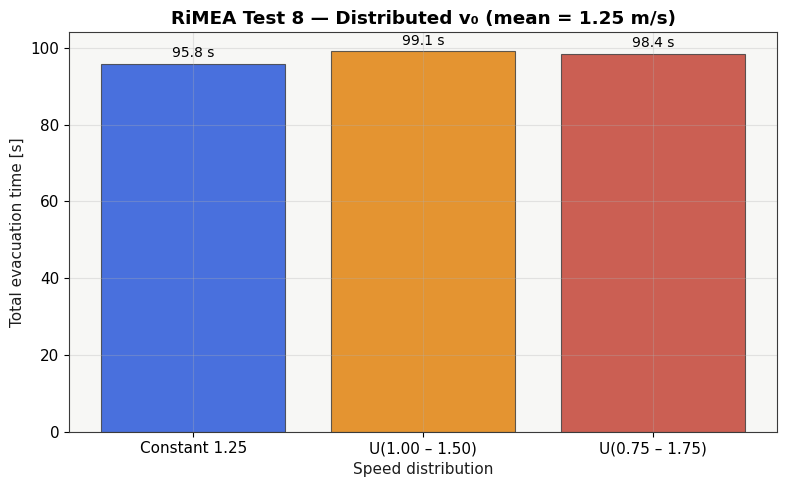

In [24]:
fig, ax = plt.subplots()

colors = ["#1d4ed8", "#e07b00", "#c0392b"]
bars = ax.bar(df_dist["label"], df_dist["evac_time"],
              color=colors, alpha=0.8, edgecolor="#3a3a3a", linewidth=0.8)

for bar, row in zip(bars, dist_results):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{row['evac_time']:.1f} s",
            ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Speed distribution")
ax.set_ylabel("Total evacuation time [s]")
ax.set_title("RiMEA Test 8 — Distributed v₀ (mean = 1.25 m/s)")
plt.tight_layout()
plt.show()

## Acceptance Test

Per RiMEA Test 8, the model should demonstrate that:
1. **Monotonicity**: evacuation time strictly decreases as constant v₀ increases.
2. **Distribution sensitivity**: runs with identical mean v₀ but different spreads should produce results within a reasonable tolerance of each other (wider spread → slightly different time due to faster + slower agents mixing).

In [25]:
def test_rimea08_parameter():
    # ── 1. Monotonicity of constant-v0 results ────────────────────────────
    times = df_constant["evac_time"].tolist()
    for i in range(len(times) - 1):
        assert times[i] >= times[i + 1], (
            f"Evacuation time did NOT decrease from "
            f"v0={CONSTANT_V0_VALUES[i]} ({times[i]:.1f}s) to "
            f"v0={CONSTANT_V0_VALUES[i+1]} ({times[i+1]:.1f}s) — "
            f"monotonicity violated."
        )
    print(f"PASS  Monotonicity: times {[f'{t:.1f}' for t in times]} are strictly decreasing.")


    # ── 2. Distribution sensitivity ───────────────────────────────────────
    t_fixed  = df_dist.loc[df_dist["label"] == "Constant 1.25",  "evac_time"].values[0]
    t_narrow = df_dist.loc[df_dist["label"] == "U(1.00 – 1.50)", "evac_time"].values[0]
    t_wide   = df_dist.loc[df_dist["label"] == "U(0.75 – 1.75)", "evac_time"].values[0]

    tol = 0.3 * t_fixed   # allow up to 30 % deviation for stochastic spread
    assert abs(t_narrow - t_fixed) < tol, (
        f"FAIL  U(1.0-1.5) evac time ({t_narrow:.1f}s) deviates > 30% "
        f"from constant 1.25 ({t_fixed:.1f}s)."
    )
    assert abs(t_wide - t_fixed) < tol, (
        f"FAIL  U(0.75-1.75) evac time ({t_wide:.1f}s) deviates > 30% "
        f"from constant 1.25 ({t_fixed:.1f}s)."
    )
    print(
        f"PASS  Distribution sensitivity: fixed={t_fixed:.1f}s, "
        f"U(1.0-1.5)={t_narrow:.1f}s, U(0.75-1.75)={t_wide:.1f}s — "
        f"all within 30% of fixed mean."
    )
    print()
    print("All RiMEA Test 8 acceptance criteria passed.")

test_rimea08_parameter()

PASS  Monotonicity: times ['103.4', '95.8', '89.5', '82.3'] are strictly decreasing.
PASS  Distribution sensitivity: fixed=95.8s, U(1.0-1.5)=99.1s, U(0.75-1.75)=98.4s — all within 30% of fixed mean.

All RiMEA Test 8 acceptance criteria passed.
